In [10]:
import os
import sys
sys.path.append(os.path.abspath('../../'))
from utlis.Ca_tools.roi_spike_vis_utlis import load_minian_data_specific, calculate_dff

# minian_nc_path = "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/minian_dataset_wnd1000_stp700_max25_diff3.5_pnrauto.nc"
minian_nc_path =  "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/minian_dataset_wnd1500_stp700_max25_diff3.5_pnr1.1.nc"
minian_path = "/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20240919-V1-R1/customEntValHere/2024_12_18/11_33_01/My_V4_Miniscope/"
# '/data/big_rim/rsync_dcc_sum/Oct3V1mini_sorted/20241002-pmc-r2/customEntValHere/2024_10_25/15_50_39/My_V4_Miniscope/' # minian_dataset.nc'/data/big_rim/mir_data/Oct3V1mini/Oct3V1mini_sorted/20241002-pmc-r2/customEntValHere/2024_10_25/17_09_14/My_V4_Miniscope' 
mini_timestamps = os.path.join(minian_path, 'timeStamps.csv')
data, ts = load_minian_data_specific(minian_nc_path, mini_timestamps)

dF_F = calculate_dff(data)

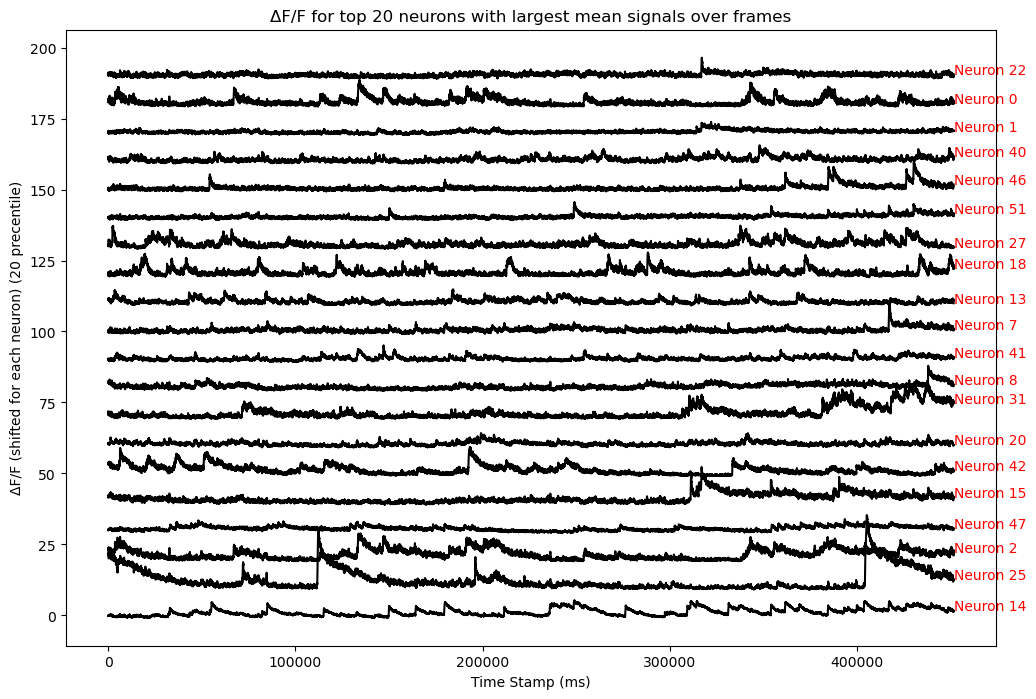

Top 20 neuron indices by mean ΔF/F (20 precentile) value:
[14 25  2 47 15 42 20 31  8 41  7 13 18 27 51 46 40  1  0 22]


In [11]:
from matplotlib import pyplot as plt
import numpy as np


C = data['C'].values

# Get the number of neurons and frames
num_neuron, num_frame = C.shape

# Calculate the mean across frames for each neuron
mean_C = np.mean(C, axis=1)

# Get the indices that would sort the neurons by their mean values in descending order
sorted_indices = np.argsort(mean_C)[::-1]

# Select the top 10-20 neurons (here we choose 20)
top_neurons = 20
selected_indices = sorted_indices[:top_neurons]

# Plot the ΔF/F values for each selected neuron and print their indices for manual selection, with timestamps
plt.figure(figsize=(12, 8))
for i, neuron_index in enumerate(selected_indices):
    plt.plot(ts, dF_F[neuron_index] + i * 10, color='black', label=f'Neuron {neuron_index}')  # Set the color to black
    plt.text(ts[-1], dF_F[neuron_index][-1] + i * 10, f'Neuron {neuron_index}', color='red')  # Annotate each neuron index

plt.xlabel('Time Stamp (ms)')
plt.ylabel('ΔF/F (shifted for each neuron) (20 precentile)')
plt.title('ΔF/F for top 20 neurons with largest mean signals over frames')
plt.show()

# Print the selected neuron indices for reference
print("Top 20 neuron indices by mean ΔF/F (20 precentile) value:")
print(selected_indices)


In [12]:
# from utlis.Ca_tools.roi_spike_vis_utlis import overlay_roi_edges_exclude
# Provide manually selected neurons
# df = pd.DataFrame({f'calcium_roi{i}': dF_F[i] for i in range(dF_F.shape[0])}, index=ts)
# selected_neurons = [10, 21,  3, 36, 11, 33, 25,  5, 32,  9, 14, 23, 35, 37,  2,  0, 17, 20, 34, 12]
# [1,44,35,6] #[54, 57, 66, 38, 42, 37, 51]  # Replace with your manual selection
# excluded_neurons = [3,8,46,75,78,55,11,56, 18, 84, 10, 77, 76, 74, 7, 2, 9, 17, 10, 12, 14, 15, 16, 18, 19, 13, 17, 0, 20, 60, 63, 70, 79, ]  # List of numbers you want to exclude

# Plot signals and ΔF/F
# plot_calcium_signals(df, selected_neurons)
# plot_dff(dF_F, ts, selected_neurons)

# Overlay ROI edges
max_proj = data['max_proj'].values
# manual_selection = [50, 57, 40, 62]  # Replace with your manual selection
# overlay_roi_edges(data, max_proj, selected_neurons)
# overlay_roi_edges_exclude(data, max_proj, excluded_neurons)

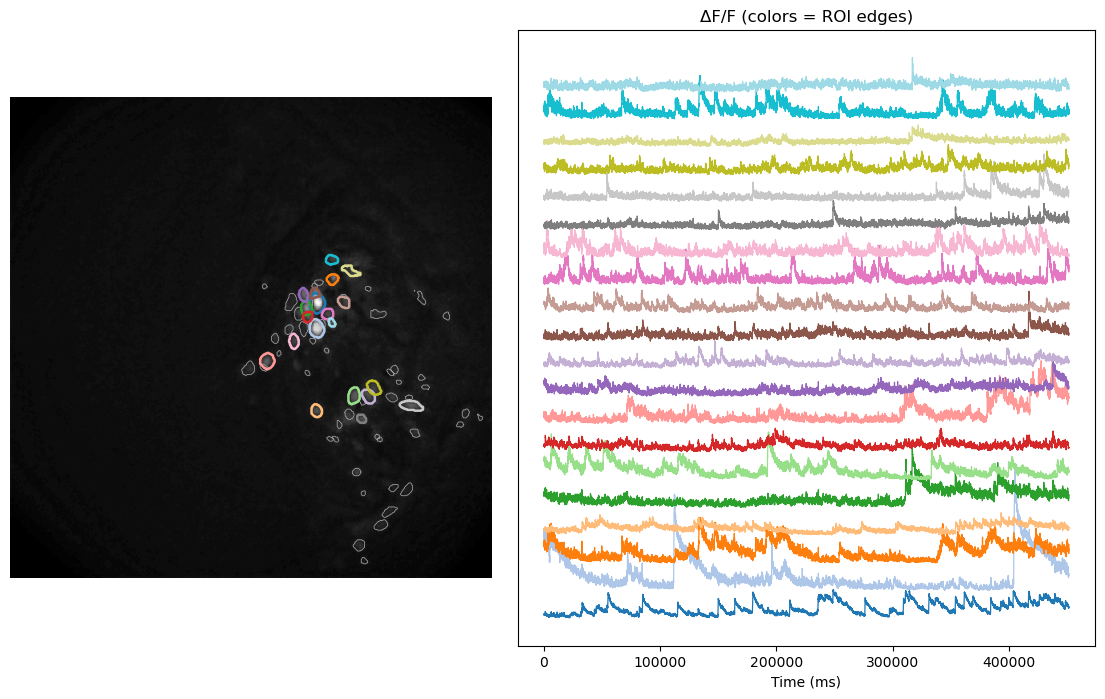

In [13]:
from utlis.present_vis.colorful_roi_dff import overlay_and_dff
fig4, _ = overlay_and_dff(data, max_proj, dF_F, ts, selected_indices, show_ids=False)
